
Hidden Layers: [8], Activation: relu


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9667
Test Loss: 0.1827

Hidden Layers: [8], Activation: tanh
Test Accuracy: 0.9667
Test Loss: 0.2044

Hidden Layers: [8], Activation: sigmoid
Test Accuracy: 0.9000
Test Loss: 0.4440

Hidden Layers: [16, 8], Activation: relu
Test Accuracy: 1.0000
Test Loss: 0.0700

Hidden Layers: [16, 8], Activation: tanh
Test Accuracy: 1.0000
Test Loss: 0.0653

Hidden Layers: [16, 8], Activation: sigmoid
Test Accuracy: 0.9000
Test Loss: 0.4737

Hidden Layers: [32, 16, 8], Activation: relu
Test Accuracy: 1.0000
Test Loss: 0.0361

Hidden Layers: [32, 16, 8], Activation: tanh
Test Accuracy: 1.0000
Test Loss: 0.0560

Hidden Layers: [32, 16, 8], Activation: sigmoid
Test Accuracy: 0.9333
Test Loss: 0.3624


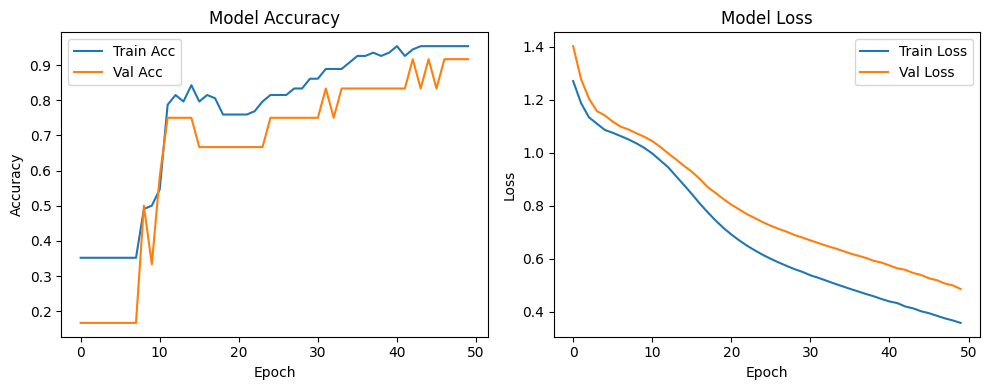

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load and preprocess data
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)
classes = iris.target_names

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

# Create MLP model
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()
    model.add(Dense(hidden_layers[0], input_dim=input_dim, activation=activation))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))

    model.add(Dense(output_dim, activation='softmax'))
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train and evaluate different configurations
hidden_layer_configs = [[8], [16, 8], [32, 16, 8]]
activations = ['relu', 'tanh', 'sigmoid']

for hidden_layers in hidden_layer_configs:
    for activation in activations:
        print(f"\nHidden Layers: {hidden_layers}, Activation: {activation}")

        model = create_mlp(4, 3, hidden_layers, activation)

        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy and loss
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predict new Iris flower
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
user_input_scaled = scaler.transform(user_input)

prediction = model.predict(user_input_scaled, verbose=0)
predicted_class = classes[np.argmax(prediction)]

print(f"\nPredicted Iris Species: {predicted_class}")